In [1]:
import yfinance as yf
import datetime

tcs = yf.download("TCS.NS", start="2020-01-01", end=datetime.date.today())
print(tcs)

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open   Volume
Ticker           TCS.NS       TCS.NS       TCS.NS       TCS.NS   TCS.NS
Date                                                                   
2020-01-01  1831.109863  1844.879346  1819.620995  1831.447686  1354908
2020-01-02  1822.704346  1841.542618  1815.566134  1841.542618  2380752
2020-01-03  1859.028687  1877.909233  1828.068187  1828.068187  4655761
2020-01-06  1858.860352  1880.401827  1848.258525  1862.704068  3023209
2020-01-07  1863.422241  1870.855997  1844.795159  1858.902673  2429317
...                 ...          ...          ...          ...      ...
2026-08-06  2373.000000  2434.500000  2368.500000  2417.000000  2729141
2026-08-07  2452.699951  2457.699951  2375.000000  2375.000000  4547979
2026-08-10  2425.699951  2472.899902  2423.500000  2452.699951  2322023
2026-08-11  2445.699951  2456.600098  2428.000000  2438.000000  1514105
2026-08-12  2349.699951  2445.800049  2300.100098  2445.699951  

In [2]:
tcs.columns = tcs.columns.get_level_values(0)
print(tcs.columns)  

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [3]:
tcs.to_csv(r"C:\Users\mukesh sharma\OneDrive\Desktop\Stock Price Prediction\Raw_Data\TCS_rawdata.csv")

print(f"Data updated successfully till {tcs.index[-1].date()}")
print(f"Total rows: {len(tcs)}")

Data updated successfully till 2026-08-12
Total rows: 1641


In [4]:
tcs.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-08-06,2373.000000,2434.500000,2368.500000,2417.000000,2729141
2026-08-07,2452.699951,2457.699951,2375.000000,2375.000000,4547979
2026-08-10,2425.699951,2472.899902,2423.500000,2452.699951,2322023
2026-08-11,2445.699951,2456.600098,2428.000000,2438.000000,1514105
2026-08-12,2349.699951,2445.800049,2300.100098,2445.699951,7022647


In [5]:
tcs.shape

(1641, 5)

In [6]:
tcs.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1641 entries, 2020-01-01 to 2026-08-12
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1641 non-null   float64
 1   High    1641 non-null   float64
 2   Low     1641 non-null   float64
 3   Open    1641 non-null   float64
 4   Volume  1641 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 76.9 KB


In [7]:
tcs.describe()

Price,Close,High,Low,Open,Volume
count,1641.000000,1641.000000,1641.000000,1641.000000,1.641000e+03
mean,2934.963242,2964.063741,2907.903981,2936.597026,2.842298e+06
std,601.934636,604.226764,599.481518,601.934126,1.800596e+06
min,1395.590576,1437.466376,1275.145533,1330.218221,0.000000e+00
25%,2647.911621,2680.565375,2623.128277,2657.203944,1.732539e+06
50%,2981.005859,3007.775208,2956.682053,2983.487608,2.413831e+06
75%,3284.910400,3312.938366,3257.747125,3286.549558,3.374385e+06
max,4230.709961,4266.478796,4191.920798,4251.380667,1.983933e+07


In [8]:
tcs.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [9]:
import matplotlib.pyplot as plt

In [10]:
plt.figure(figsize=(14,5))


<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

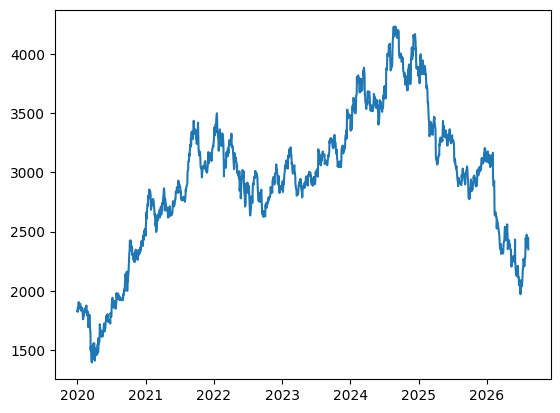

In [11]:

plt.plot(tcs.index, tcs['Close'])


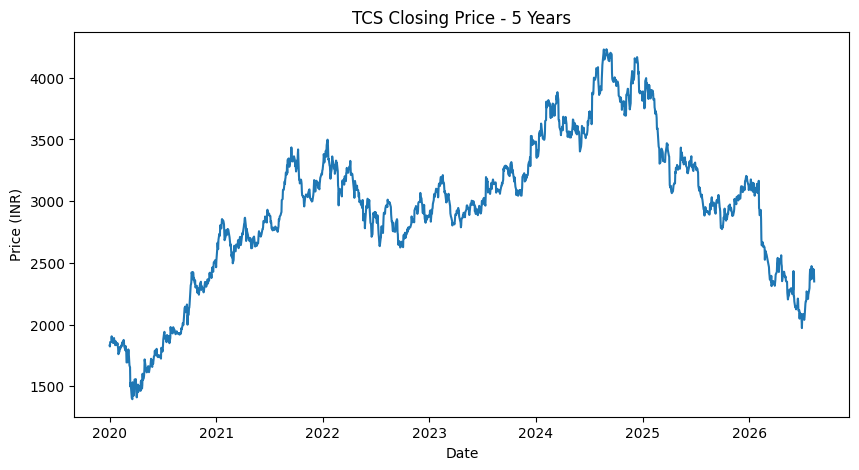

In [12]:
plt.figure(figsize=(10,5))
plt.plot(tcs.index, tcs['Close'])
plt.title('TCS Closing Price - 5 Years')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.show()

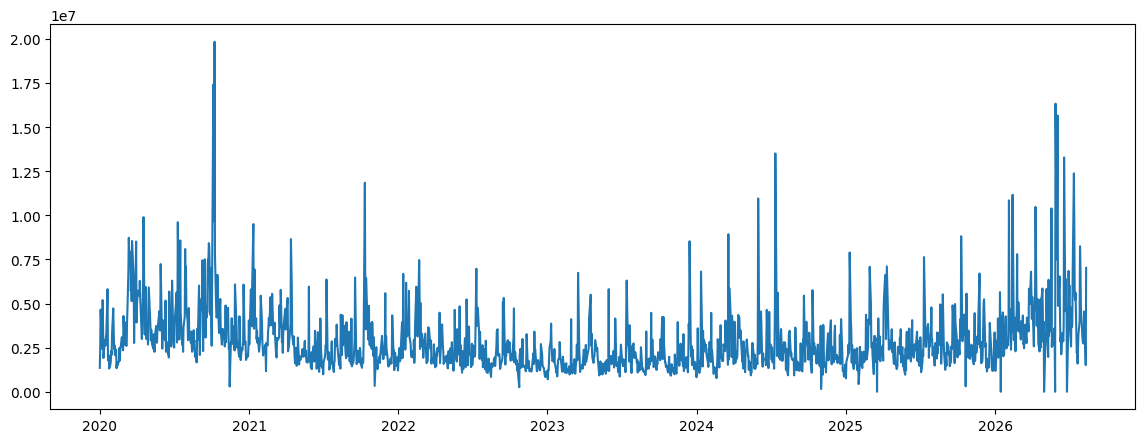

In [13]:
plt.figure(figsize=(14,5))
plt.plot(tcs.index, tcs['Volume'])


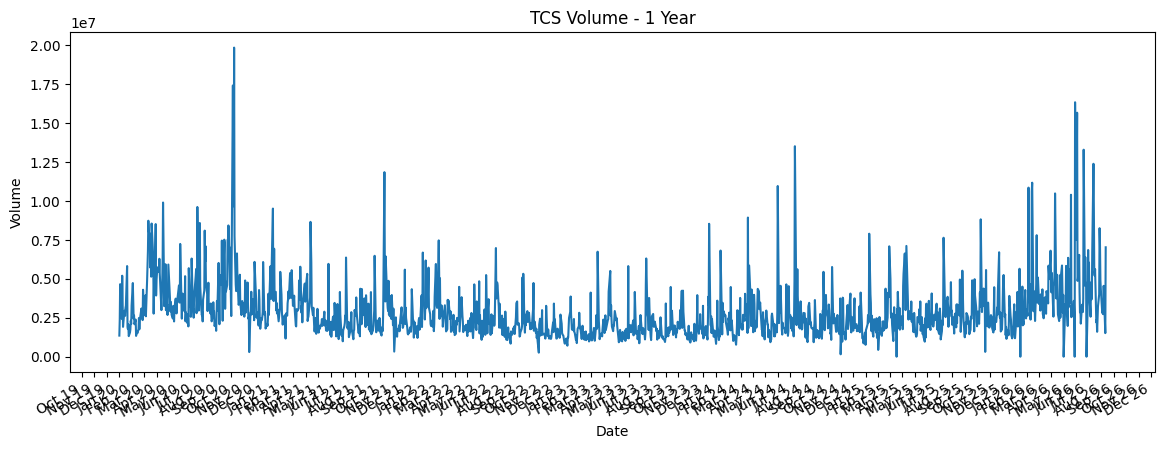

In [14]:
plt.figure(figsize=(14,5))
plt.plot(tcs.index, tcs['Volume'])
plt.title('TCS Volume - 1 Year')
plt.xlabel('Date')
plt.ylabel('Volume')
import matplotlib.dates as mdates

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.gcf().autofmt_xdate()
plt.show()

In [15]:
tcs['MA20'] = tcs['Close'].rolling(window=20).mean()
tcs['MA50'] = tcs['Close'].rolling(window=50).mean()

In [16]:
print(tcs['MA20'].isnull().sum())
print(tcs['MA50'].isnull().sum())
print(tcs['MA20'].head(30))

19
49
Date
2020-01-01            NaN
2020-01-02            NaN
2020-01-03            NaN
2020-01-06            NaN
2020-01-07            NaN
2020-01-08            NaN
2020-01-09            NaN
2020-01-10            NaN
2020-01-13            NaN
2020-01-14            NaN
2020-01-15            NaN
2020-01-16            NaN
2020-01-17            NaN
2020-01-20            NaN
2020-01-21            NaN
2020-01-22            NaN
2020-01-23            NaN
2020-01-24            NaN
2020-01-27            NaN
2020-01-28    1858.178882
2020-01-29    1857.836438
2020-01-30    1857.205188
2020-01-31    1852.268445
2020-02-03    1848.332867
2020-02-04    1844.391437
2020-02-05    1840.006012
2020-02-06    1836.577692
2020-02-07    1833.530255
2020-02-10    1832.538031
2020-02-11    1830.484814
Name: MA20, dtype: float64


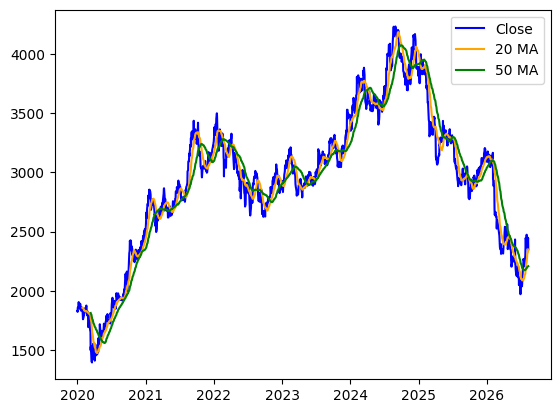

In [17]:
plt.plot(tcs.index, tcs['Close'], label='Close', color='blue')
plt.plot(tcs.index, tcs['MA20'], label='20 MA', color='orange')
plt.plot(tcs.index, tcs['MA50'], label='50 MA', color='green')
plt.legend()

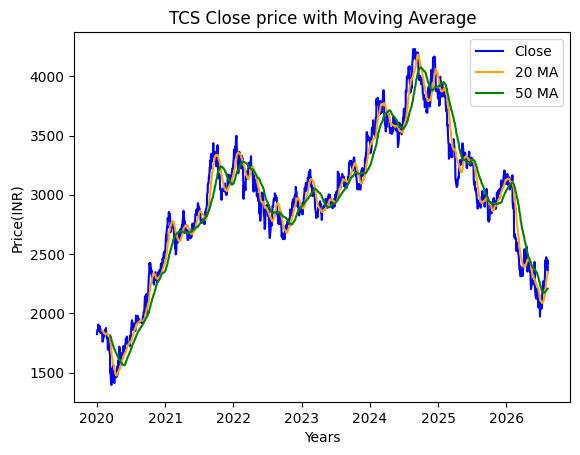

In [18]:
plt.plot(tcs.index, tcs['Close'], label='Close', color='blue')
plt.plot(tcs.index, tcs['MA20'], label='20 MA', color='orange')
plt.plot(tcs.index, tcs['MA50'], label='50 MA', color='green')
plt.title('TCS Close price with Moving Average')
plt.xlabel('Years')
plt.ylabel('Price(INR)')
plt.legend()

In [19]:
tcs['Daily_Return'] = tcs['Close'].pct_change() * 100


In [20]:
tcs[['Close', 'Daily_Return']].head(10)

Price,Close,Daily_Return
Date,,
2020-01-01,1831.109863,NaN
2020-01-02,1822.704346,-0.459040
2020-01-03,1859.028687,1.992882
2020-01-06,1858.860352,-0.009055
2020-01-07,1863.422241,0.245413
2020-01-08,1905.153442,2.239492
2020-01-09,1870.602295,-1.813562
2020-01-10,1869.926880,-0.036107
2020-01-13,1850.328369,-1.048090


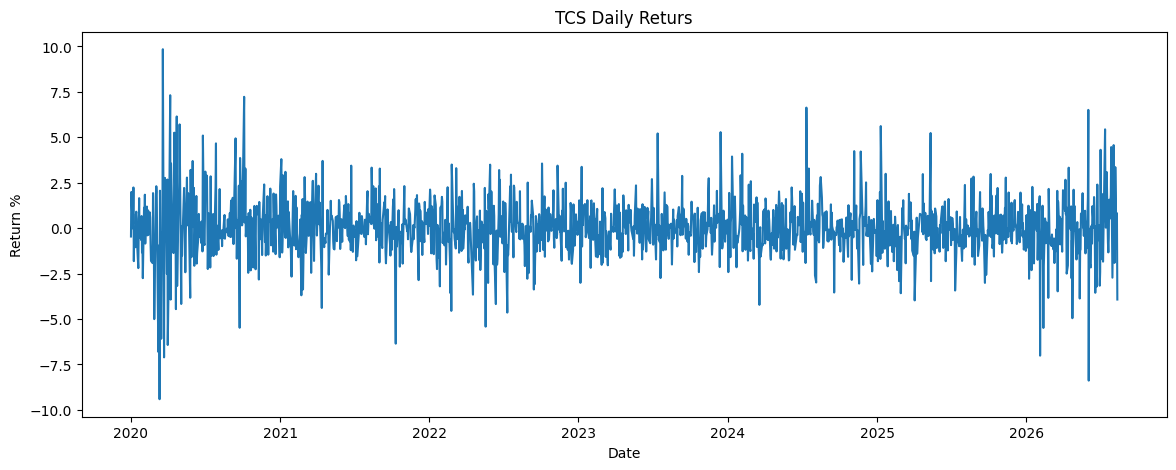

In [21]:
plt.figure(figsize = (14,5))
plt.plot(tcs.index, tcs['Daily_Return'])
plt.title('TCS Daily Returs')
plt.xlabel('Date')
plt.ylabel('Return %')
plt.show()

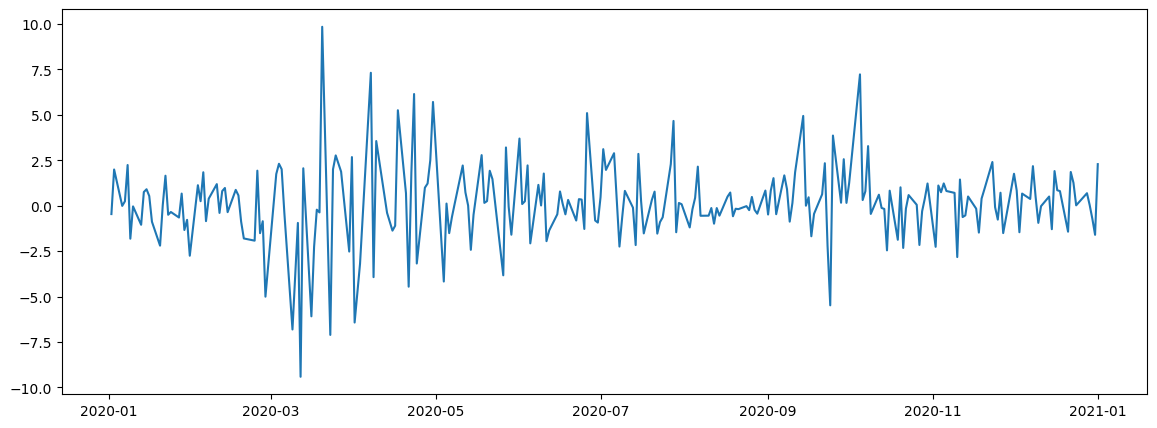

In [22]:
filtered = tcs['2020-01-01': '2021-01-01']
plt.figure(figsize = (14,5))
plt.plot(filtered.index, filtered['Daily_Return'])

plt.show()
           


In [23]:
delta = tcs['Close'].diff()

In [24]:
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0,0)

In [25]:
avg_gain = gain.rolling(window =14).mean()
avg_loss = loss.rolling(window = 14).mean()

In [26]:
rs = avg_gain / avg_loss
tcs['RSI'] = 100 - (100/(1 + rs))

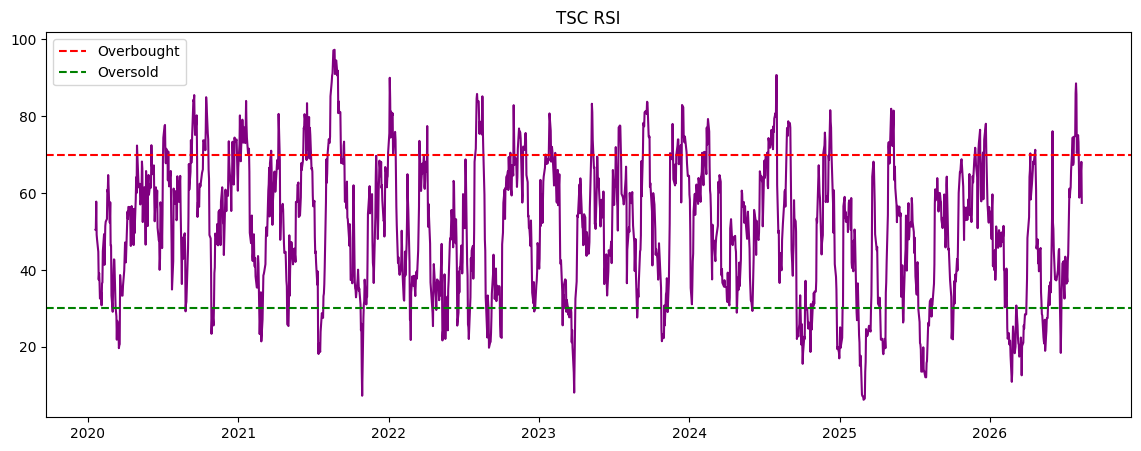

In [27]:
plt.figure(figsize = (14,5))
plt.plot(tcs.index, tcs['RSI'], color = 'purple')
plt.axhline(70, color = 'red', linestyle = '--', label = 'Overbought')
plt.axhline(30, color = 'green', linestyle = '--', label = 'Oversold')
plt.title ('TSC RSI')
plt.legend()
plt.show()

In [28]:
print(tcs['RSI'].isnull().sum())
print(tcs['RSI'].dropna().head(20))

13
Date
2020-01-20    50.474580
2020-01-21    50.593885
2020-01-22    57.784188
2020-01-23    49.169217
2020-01-24    47.927217
2020-01-27    44.729270
2020-01-28    37.473620
2020-01-29    39.197990
2020-01-30    36.876082
2020-01-31    32.564718
2020-02-03    34.064820
2020-02-04    30.802377
2020-02-05    36.551274
2020-02-06    36.716167
2020-02-07    44.882763
2020-02-10    49.318814
2020-02-11    41.329900
2020-02-12    46.469820
2020-02-13    51.426290
2020-02-14    52.548116
Name: RSI, dtype: float64


In [29]:
tcs[['Close', 'Daily_Return', 'MA20', 'MA50', 'RSI']].head(20)

Price,Close,Daily_Return,MA20,MA50,RSI
Date,,,,,
2020-01-01,1831.109863,NaN,NaN,NaN,NaN
2020-01-02,1822.704346,-0.459040,NaN,NaN,NaN
2020-01-03,1859.028687,1.992882,NaN,NaN,NaN
2020-01-06,1858.860352,-0.009055,NaN,NaN,NaN
2020-01-07,1863.422241,0.245413,NaN,NaN,NaN
2020-01-08,1905.153442,2.239492,NaN,NaN,NaN
2020-01-09,1870.602295,-1.813562,NaN,NaN,NaN
2020-01-10,1869.926880,-0.036107,NaN,NaN,NaN
2020-01-13,1850.328369,-1.048090,NaN,NaN,NaN


In [30]:
print(tcs.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA20', 'MA50',
       'Daily_Return', 'RSI'],
      dtype='str', name='Price')


In [31]:
tcs.dropna(inplace=True)
print(tcs.shape)
tcs[['Close', 'Daily_Return', 'MA20', 'MA50', 'RSI']].head(20)

(1592, 9)


Price,Close,Daily_Return,MA20,MA50,RSI
Date,,,,,
2020-03-12,1498.500000,-9.410363,1772.863153,1813.248098,21.863093
2020-03-13,1529.361816,2.059514,1757.434485,1807.213137,26.781992
2020-03-16,1436.311157,-6.084280,1736.455798,1799.485273,24.555182
2020-03-17,1403.798584,-2.263616,1714.179590,1790.380671,19.656468
2020-03-18,1400.750610,-0.217123,1690.944519,1781.218477,20.375073
2020-03-19,1395.590576,-0.368376,1666.922278,1771.861843,20.688720
2020-03-20,1532.987671,9.845086,1650.591168,1764.418528,38.673378
2020-03-23,1424.033936,-7.107281,1630.486676,1755.487161,33.439700
2020-03-24,1452.562378,2.003354,1613.563373,1747.139871,33.356376


In [32]:
x = tcs[['Close', 'MA20', 'MA50', 'Daily_Return', 'RSI']]
y = tcs['Close'].shift(-1)
x = x[:-1]
y = y[:-1]

In [33]:
print(type(tcs['Close']))
print(type(tcs[['Close']]))



<class 'pandas.Series'>
<class 'pandas.DataFrame'>


In [34]:
split = int(len(tcs)*0.8)   

x_train = x[:split]    
x_test =  x[split:]
y_train = y[:split]
y_test =  y[split:]

print(x_train.shape, x_test.shape)

(1273, 5) (318, 5)


In [35]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)


print("Original training data:\n", x_train.head(10))
print("Scaled training data:\n", x_train_scaled )


Original training data:
 Price             Close         MA20         MA50  Daily_Return        RSI
Date                                                                      
2020-03-12  1498.500000  1772.863153  1813.248098     -9.410363  21.863093
2020-03-13  1529.361816  1757.434485  1807.213137      2.059514  26.781992
2020-03-16  1436.311157  1736.455798  1799.485273     -6.084280  24.555182
2020-03-17  1403.798584  1714.179590  1790.380671     -2.263616  19.656468
2020-03-18  1400.750610  1690.944519  1781.218477     -0.217123  20.375073
2020-03-19  1395.590576  1666.922278  1771.861843     -0.368376  20.688720
2020-03-20  1532.987671  1650.591168  1764.418528      9.845086  38.673378
2020-03-23  1424.033936  1630.486676  1755.487161     -7.107281  33.439700
2020-03-24  1452.562378  1613.563373  1747.139871      2.003354  33.356376
2020-03-25  1492.775146  1596.923450  1739.988806      2.768402  33.390596
Scaled training data:
 [[0.03629809 0.11026774 0.10088284 0.         0.1717

In [36]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
x_test_scaled = scaler.transform(x_test)
prediction = model.predict(x_test_scaled)
print(prediction[:10])

[3269.32761282 3272.49898497 3264.44354405 3431.5167231  3336.05033963
 3365.74549912 3395.06776725 3378.10413278 3338.22778256 3318.49164421]


In [38]:
import pandas as pd

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': prediction
})

print(results.head(20))

         Actual    Predicted
0   3271.157471  3269.327613
1   3263.001221  3272.498985
2   3433.819336  3264.443544
3   3333.851318  3431.516723
4   3365.814453  3336.050340
5   3395.406494  3365.745499
6   3377.765381  3395.067767
7   3337.455566  3378.104133
8   3318.012207  3338.227783
9   3344.094971  3318.491644
10  3297.809570  3343.634248
11  3333.471924  3298.621888
12  3355.002197  3332.796225
13  3318.391357  3354.400787
14  3317.442627  3318.799435
15  3317.822754  3317.283451
16  3284.910400  3317.612998
17  3272.011475  3285.468374
18  3229.709961  3272.249978
19  3235.164062  3230.655454


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test.values[:len(prediction)], prediction)
rmse = np.sqrt(mean_squared_error(y_test.values[:len(prediction)], prediction))

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

MAE: 31.403171991858162
RMSE: 44.06346870000207


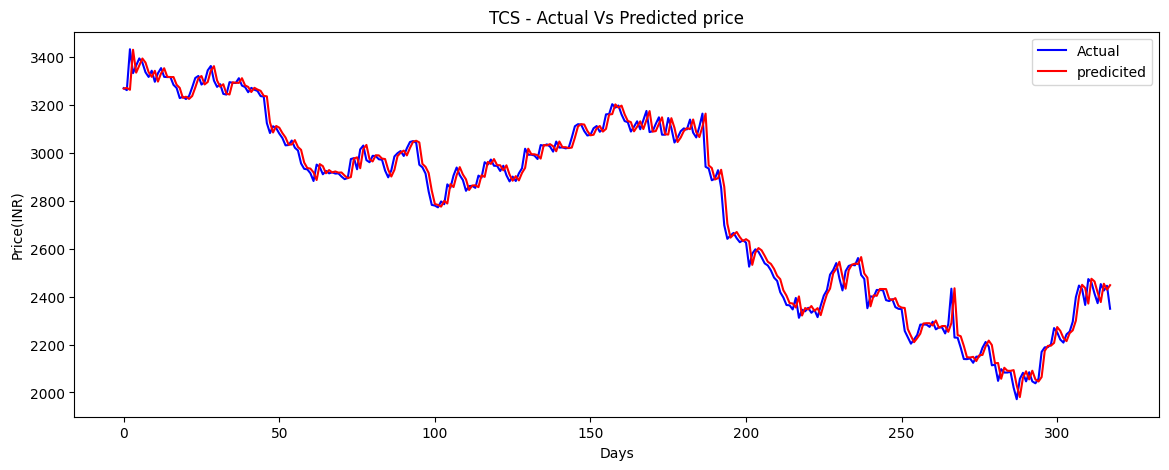

In [40]:
plt.figure(figsize= (14,5))
plt.plot(y_test.values[:len(prediction)], label = 'Actual', color = 'blue')
plt.plot(prediction, label = 'predicited', color = 'red')
plt.title('TCS - Actual Vs Predicted price')
plt.xlabel('Days')
plt.ylabel('Price(INR)')
plt.legend()
plt.show()


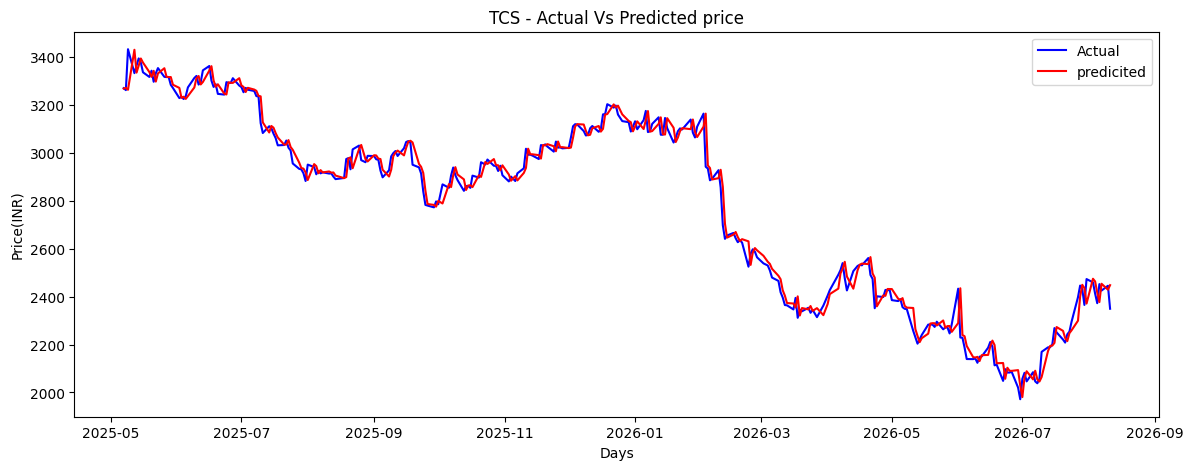

In [41]:
plt.figure(figsize= (14,5))
plt.plot(y_test.index, y_test.values[:len(prediction)], label = 'Actual', color = 'blue')
plt.plot(y_test.index[:len(prediction)], prediction, label = 'predicited', color = 'red')
plt.title('TCS - Actual Vs Predicted price')
plt.xlabel('Days')
plt.ylabel('Price(INR)')
plt.legend()
plt.show()


In [42]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators= 200, random_state= 42)
rf_model.fit(x_train_scaled, y_train)

rf_prediction = rf_model.predict(x_test_scaled)

In [43]:
rf_mae = mean_absolute_error(y_test.values[:len(rf_prediction)], rf_prediction)
rf_rmse = np.sqrt(mean_squared_error(y_test.values[:len(rf_prediction)], rf_prediction))

print(f'RF MAE: {rf_mae}')
print(f'RF RMSE: {rf_rmse}')

RF MAE: 53.5084177537834
RF RMSE: 72.07046652023352


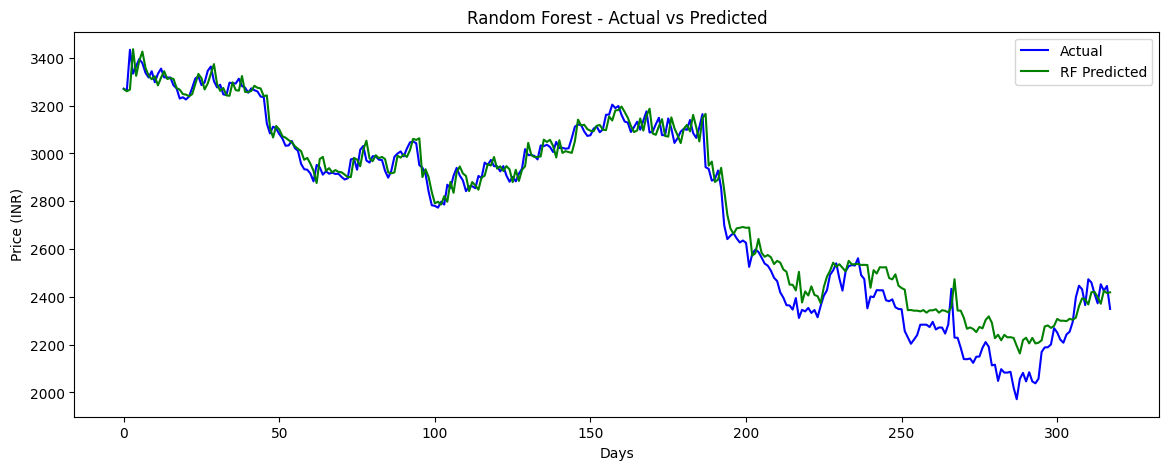

In [44]:
plt.figure(figsize=(14,5))
plt.plot(y_test.values[:len(rf_prediction)], label='Actual', color='blue')
plt.plot(rf_prediction, label='RF Predicted', color='green')
plt.title('Random Forest - Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

In [45]:
import numpy as np

def create_sequences(x, y, lookback=60):
    x_seq, y_seq = [], []
    for i in range(lookback, len(x)):
        x_seq.append(x[i-lookback:i])
        y_seq.append(y[i])
    return np.array(x_seq), np.array(y_seq)

In [46]:
from sklearn.preprocessing import MinMaxScaler

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

x_train_scaled = scaler_x.fit_transform(x_train)
x_test_scaled = scaler_x.transform(x_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

In [47]:
lookback = 60

x_train_seq, y_train_seq = create_sequences(x_train_scaled, y_train_scaled, lookback)
x_test_seq, y_test_seq = create_sequences(x_test_scaled, y_test_scaled, lookback)

print(x_train_seq.shape)
print(x_test_seq.shape)


(1213, 60, 5)
(258, 60, 5)


In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_lstm = Sequential()
from tensorflow.keras.layers import Input
model_lstm = Sequential()
model_lstm.add(Input(shape=(60, 5)))
model_lstm.add(LSTM(units=50, return_sequences=True))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(units=50, return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(units=1))
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.summary()
model_lstm.add(Dropout(0.2))

model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(units=1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,453 (122.86 KB)

 Trainable params: 31,453 (122.86 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history = model_lstm.fit(
    x_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - loss: 0.1394 - val_loss: 0.1130
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1084 - val_loss: 0.0686
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0996 - val_loss: 0.0615
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0894 - val_loss: 0.0714
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0803 - val_loss: 0.0633
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0743 - val_loss: 0.0493
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0671 - val_loss: 0.0429
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0608 - val_loss: 0.0467
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0550 - val_loss: 0.0356
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0452 - val_loss: 0.0392
Epoch 11/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0432 - val_loss: 0.0300
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0

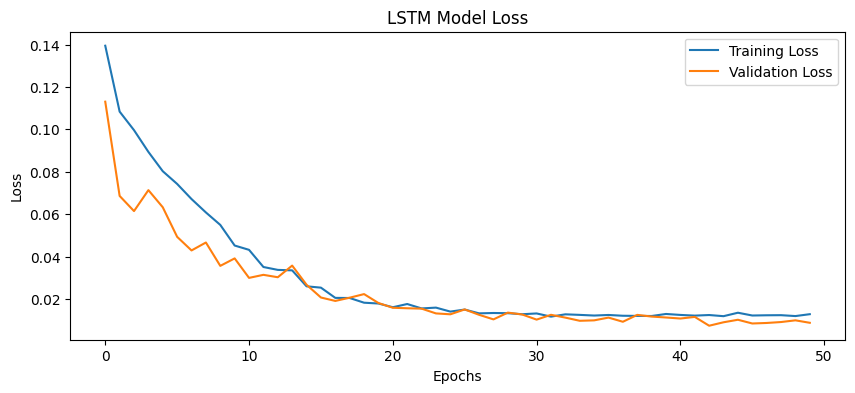

In [50]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [51]:
lstm_prediction_scaled = model_lstm.predict(x_test_seq)

lstm_prediction = scaler_y.inverse_transform(lstm_prediction_scaled)

y_test_actual = scaler_y.inverse_transform(y_test_seq)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step


In [52]:
lstm_mae = mean_absolute_error(y_test_actual, lstm_prediction)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_prediction))

print(f'LSTM MAE: {lstm_mae}')
print(f'LSTM RMSE: {lstm_rmse}')

LSTM MAE: 157.93238676795664
LSTM RMSE: 205.41443575272677


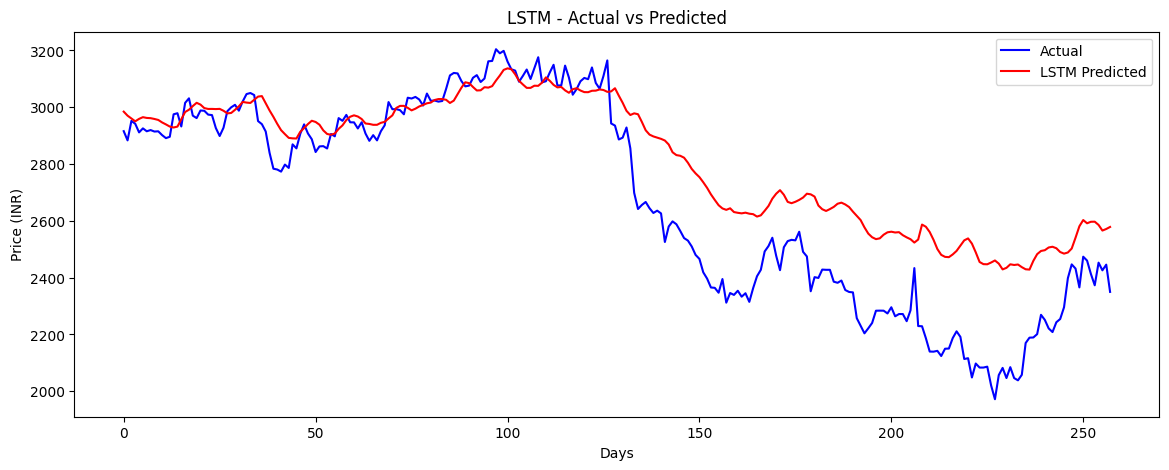

In [53]:
plt.figure(figsize=(14,5))
plt.plot(y_test_actual, label='Actual', color='blue')
plt.plot(lstm_prediction, label='LSTM Predicted', color='red')
plt.title('LSTM - Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

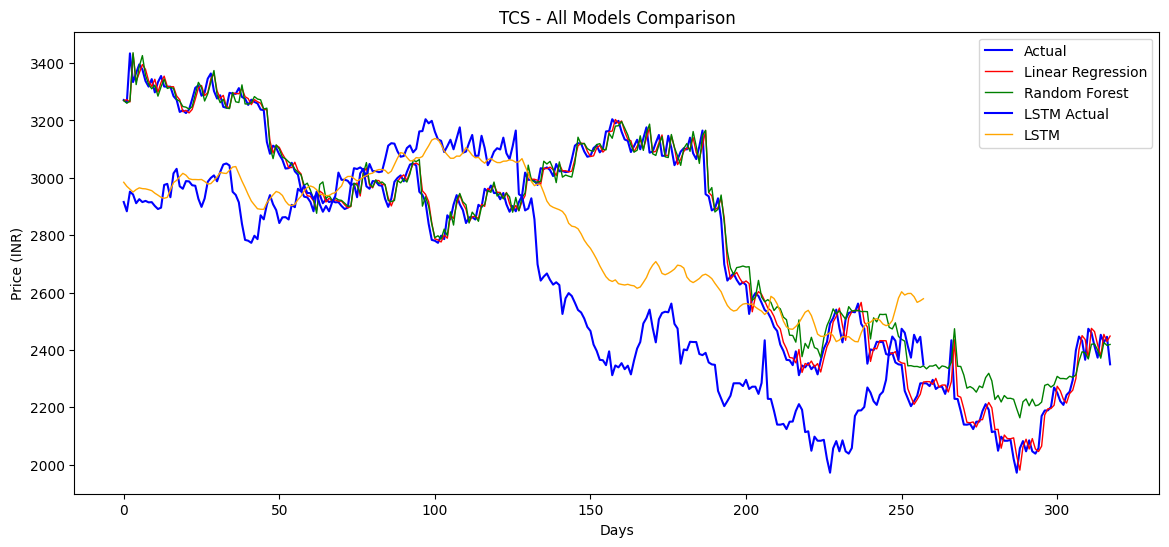

In [54]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values[:len(prediction)], label='Actual', color='blue', linewidth=1.5)
plt.plot(prediction, label='Linear Regression', color='red', linewidth=1)
plt.plot(rf_prediction, label='Random Forest', color='green', linewidth=1)
plt.plot(y_test_actual[:len(lstm_prediction)], label='LSTM Actual', color='blue')
plt.plot(lstm_prediction, label='LSTM', color='orange', linewidth=1)
plt.title('TCS - All Models Comparison')
plt.xlabel('Days')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

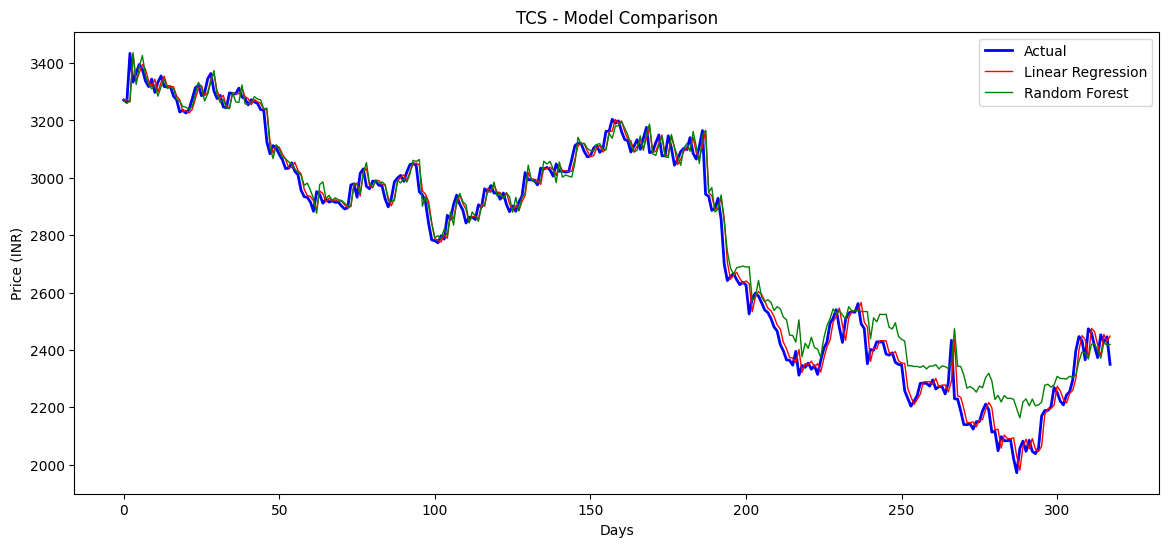

In [55]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values[:len(prediction)], label='Actual', color='blue', linewidth=2)
plt.plot(prediction, label='Linear Regression', color='red', linewidth=1)
plt.plot(rf_prediction, label='Random Forest', color='green', linewidth=1)
plt.title('TCS - Model Comparison')
plt.xlabel('Days')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

In [56]:

last_row = tcs[['Close', 'MA20', 'MA50', 'Daily_Return', 'RSI']].iloc[-1]
print(last_row)

Price
Close           2349.699951
MA20            2348.940015
MA50            2208.178391
Daily_Return      -3.925257
RSI               57.456022
Name: 2026-08-12 00:00:00, dtype: float64


In [57]:

last_row_scaled = scaler_x.transform(last_row.values.reshape(1, -1))


predicted_price = model.predict(last_row_scaled)
print(f'Predicted TCS price for tomorrow: ₹{predicted_price[0]:.2f}')

Predicted TCS price for tomorrow: ₹2355.08


c:\Users\mukesh sharma\OneDrive\Desktop\Stock Price Prediction\lstm_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [58]:
import os

PREDICTION_LOG = r"C:\Users\mukesh sharma\OneDrive\Desktop\Stock Price Prediction\Raw_Data\prediction_log.csv"

def save_predictions(predicted_dates, predicted_prices, today):
    new_rows = pd.DataFrame({
        'predicted_for_date': [d.date() for d in predicted_dates],
        'predicted_price': predicted_prices,
        'predicted_on_date': today.date()
    })
    
    if os.path.exists(PREDICTION_LOG):
        existing = pd.read_csv(PREDICTION_LOG)
        combined = pd.concat([existing, new_rows]).drop_duplicates(
            subset='predicted_for_date', keep='last')
        combined.to_csv(PREDICTION_LOG, index=False)
    else:
        new_rows.to_csv(PREDICTION_LOG, index=False)

def load_prediction_log():
    if os.path.exists(PREDICTION_LOG):
        df = pd.read_csv(PREDICTION_LOG)
        df['predicted_for_date'] = pd.to_datetime(df['predicted_for_date'])
        return df
    return pd.DataFrame(columns=['predicted_for_date', 'predicted_price', 'predicted_on_date'])

In [59]:
import plotly.graph_objects as go
import plotly.io as pio
import pandas_market_calendars as mcal
import pandas as pd
import numpy as np

# ── CHANGE 1: Build results DataFrame (add this right after your model.predict() line) ──
# prediction = model.predict(x_test_scaled)   ← already exists in your code above
results = pd.DataFrame({
    'Actual':    y_test.values.flatten(),
    'Predicted': prediction.flatten()
}, index=x_test.index)


def predict_next_3_days():
    pio.renderers.default = 'browser'

    nse = mcal.get_calendar('NSE')
    today = tcs.index[-1]
    next_days = pd.date_range(start=today + pd.Timedelta(days=1), periods=10)
    schedule = nse.schedule(start_date=next_days[0], end_date=next_days[-1])

    if len(schedule) < 3:
        print("Not enough trading days found.")
        return

    next_trading_days = schedule.index[:3]

    all_bdays = pd.date_range(start=today + pd.Timedelta(days=1),
                              end=next_trading_days[2], freq='B')
    holidays = [d for d in all_bdays if d not in next_trading_days]

    working_data = tcs.copy()
    predicted_prices = []
    predicted_dates = []

    print(f"\nLatest data as of:  {today.date()}")
    print(f"Current Close:      ₹{float(tcs['Close'].iloc[-1]):.2f}")
    print("-" * 40)

    for i in range(3):
        last_row = working_data[['Close', 'MA20', 'MA50',
                                  'Daily_Return', 'RSI']].iloc[-1]

        # ── CHANGE 5: Use reshape instead of wrapping in DataFrame ──
        last_row_scaled = scaler_x.transform(last_row.values.reshape(1, -1))
        predicted_price = float(model.predict(last_row_scaled)[0])

        trading_day = next_trading_days[i]
        predicted_prices.append(predicted_price)
        predicted_dates.append(trading_day)

        print(f"Day {i+1} — {trading_day.date()} → ₹{predicted_price:.2f}")

        new_row = working_data.iloc[-1].copy()
        new_row['Close'] = predicted_price
        new_row['Daily_Return'] = ((predicted_price - float(working_data['Close'].iloc[-1]))
                                    / float(working_data['Close'].iloc[-1])) * 100

        temp_close = pd.concat([
            working_data['Close'],
            pd.Series([predicted_price], index=[trading_day])
        ])
        new_row['MA20'] = temp_close.rolling(20).mean().iloc[-1]
        new_row['MA50'] = temp_close.rolling(50).mean().iloc[-1]

        delta = temp_close.diff()
        gain = delta.where(delta > 0, 0)
        loss = -delta.where(delta < 0, 0)
        avg_gain = gain.rolling(14).mean().iloc[-1]
        avg_loss = loss.rolling(14).mean().iloc[-1]
        rs = avg_gain / avg_loss if avg_loss != 0 else 0
        new_row['RSI'] = 100 - (100 / (1 + rs))

        new_df = pd.DataFrame([new_row], index=[trading_day])
        working_data = pd.concat([working_data, new_df])

    # ── CHANGE 3: Removed save_predictions() and load_prediction_log() calls ──

    # Build chart
    fig = go.Figure()

    # Actual close price
    fig.add_trace(go.Scatter(
        x=tcs.index,
        y=tcs['Close'],
        name='Actual Close Price',
        line=dict(color='green', width=1.5),
        hovertemplate='Date: %{x}<br>Actual: ₹%{y:.2f}<extra></extra>'
    ))

    # ── CHANGE 2: Full backtest blue line using results DataFrame ──
    fig.add_trace(go.Scatter(
        x=results.index,
        y=results['Predicted'],
        name='Predicted — Backtest',
        line=dict(color='royalblue', width=1.5, dash='dot'),
        hovertemplate='Date: %{x}<br>Predicted: ₹%{y:.2f}<extra></extra>'
    ))

    # Future 3 day predictions
    all_x = [today] + list(predicted_dates)
    all_y = [float(tcs['Close'].iloc[-1])] + predicted_prices

    fig.add_trace(go.Scatter(
        x=all_x,
        y=all_y,
        name='3-Day Future Prediction',
        line=dict(color='red', width=2, dash='dash'),
        mode='lines+markers',
        marker=dict(size=7),
        hovertemplate='Date: %{x}<br>Predicted: ₹%{y:.2f}<extra></extra>'
    ))

    # Holiday dots
    for holiday in holidays:
        mid_price = np.interp(
            holiday.value,
            [today.value, next_trading_days[2].value],
            [float(tcs['Close'].iloc[-1]), predicted_prices[2]]
        )
        fig.add_trace(go.Scatter(
            x=[holiday],
            y=[mid_price],
            mode='markers',
            marker=dict(size=5, color='yellow'),
            name='Market Holiday',
            showlegend=False,
            hovertemplate=f"Market closed on {holiday.date()}<extra></extra>"
        ))

    fig.update_layout(
        title=f'TCS Close Price | Backtest + Next 3 Day Predictions from {today.date()}',
        xaxis_title='Date',
        yaxis_title='Price (INR)',
        hovermode='x unified',
        dragmode='pan',
        # ── CHANGE 4: Legend moved to top-right horizontal layout ──
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        xaxis=dict(
            rangeslider=dict(visible=False),
            rangeselector=dict(
                buttons=list([
                    dict(count=1,  label='1M', step='month', stepmode='backward'),
                    dict(count=3,  label='3M', step='month', stepmode='backward'),
                    dict(count=6,  label='6M', step='month', stepmode='backward'),
                    dict(count=1,  label='1Y', step='year',  stepmode='backward'),
                    dict(step='all', label='All')
                ])
            )
        ),
        modebar=dict(add=['scrollZoom'])
    )

    fig.update_xaxes(fixedrange=False)
    fig.update_yaxes(fixedrange=False)

    fig.write_html(
        "tcs_prediction.html",
        config={'scrollZoom': True, 'displayModeBar': True}
    )

    # ── CHANGE 6: Use 'file://' prefix for reliable browser opening ──
    import webbrowser, os
    webbrowser.open('file://' + os.path.realpath("tcs_prediction.html"))





In [61]:
predict_next_3_days()


Latest data as of:  2026-08-12
Current Close:      ₹2349.70
----------------------------------------
Day 1 — 2026-08-13 → ₹2355.08
Day 2 — 2026-08-14 → ₹2358.25
Day 3 — 2026-08-17 → ₹2361.46


c:\Users\mukesh sharma\OneDrive\Desktop\Stock Price Prediction\lstm_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\mukesh sharma\OneDrive\Desktop\Stock Price Prediction\lstm_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\mukesh sharma\OneDrive\Desktop\Stock Price Prediction\lstm_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
